# Decision Tree Lab Activity

# Task 1: Dataset Exploration

## Dataset

**Dataset Name:** Iris Dataset

**Source:** Scikit-learn (`load_iris()`)

### About the Dataset

The Iris dataset is a well-known benchmark dataset used for multiclass classification problems. It contains measurements of iris flowers from three different species:

- Setosa
- Versicolor
- Virginica

The dataset consists of **150 samples**, with **4 numerical input features** and **3 target classes**.

### Dataset Exploration

The following exploratory analysis was performed:

- Loaded the dataset using Scikit-learn
- Converted it into a Pandas DataFrame
- Displayed the first five records
- Identified the number of samples and features
- Listed the feature names and target classes
- Displayed the class distribution
- Checked for missing values
- Checked for duplicate records

The dataset is balanced, with **50 samples for each flower species**, making it suitable for multiclass classification experiments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

In [3]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset Shape:", df.shape)

print("Number of Samples:", df.shape[0])
print("Number of Features:", df.shape[1]-1)

Dataset Shape: (150, 5)
Number of Samples: 150
Number of Features: 4


In [5]:
print("Feature Names:\n")

for feature in iris.feature_names:
    print(feature)

Feature Names:

sepal length (cm)
sepal width (cm)
petal length (cm)
petal width (cm)


In [6]:
print("Target Classes:")

for i, name in enumerate(iris.target_names):
    print(f"{i} : {name}")

Target Classes:
0 : setosa
1 : versicolor
2 : virginica


In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
print(df["Target"].value_counts())

Target
0    50
1    50
2    50
Name: count, dtype: int64


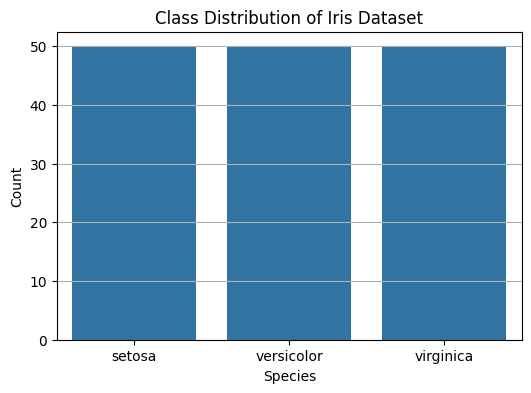

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Target",
    data=df
)

plt.xticks(
    [0,1,2],
    iris.target_names
)

plt.title("Class Distribution of Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Count")

plt.grid(axis='y')

plt.show()

In [10]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64


In [11]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 1


In [12]:
duplicates = df[df.duplicated()]

duplicates

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
142,5.8,2.7,5.1,1.9,2


In [13]:
print("Duplicate Records Before:", df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

print("Duplicate Records After:", df.duplicated().sum())
print("Dataset Shape:", df.shape)

Duplicate Records Before: 1
Duplicate Records After: 0
Dataset Shape: (149, 5)


### Duplicate Record Handling

One duplicate record was identified in the Iris dataset. Duplicate records do not contribute any new information and may slightly bias the learning process by giving additional importance to the repeated observation. Therefore, the duplicate record was removed to ensure that each sample in the dataset is unique before training the Decision Tree classifier.

## Why is the Dataset Split into Training and Testing Sets? (Task 2)

The dataset is divided into training and testing sets to evaluate how well the model performs on unseen data.

- The **training set (80%)** is used to train the Decision Tree classifier.
- The **testing set (20%)** is used to evaluate the trained model.

Keeping the testing data separate helps measure the model's ability to generalize to new data and prevents biased performance evaluation.

In [14]:
# Features
X = df.drop("Target", axis=1)

# Target
y = df["Target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (149, 4)
Target Shape: (149,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 119
Testing Samples: 30


# Task 3: Building a Decision Tree Classifier

A Decision Tree classifier was created using the default parameters provided by Scikit-learn.

The model was trained using the training dataset and then used to predict the class labels of the testing dataset. These predictions will be evaluated using standard classification metrics such as Accuracy Score, Confusion Matrix, and Classification Report.

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)

In [18]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
y_pred = dt_model.predict(X_test)

# Task 4: Visualizing the Decision Tree

The trained Decision Tree was visualized using `plot_tree()`.

### Observations

- **Root Node:** The first node of the tree, representing the initial split of the dataset.
- **Internal Nodes:** Nodes that perform additional feature-based splits.
- **Leaf Nodes:** Terminal nodes that represent the final predicted class.
- **Maximum Tree Depth:** Obtained using `get_depth()`.
- **Number of Leaf Nodes:** Obtained using `get_n_leaves()`.

### Root Feature

The first split was performed using **Petal Length (cm)**.

This feature was selected because it provides the highest reduction in impurity, allowing the Decision Tree to separate the Iris flower species effectively. In particular, it clearly distinguishes the Setosa species from the other two classes.

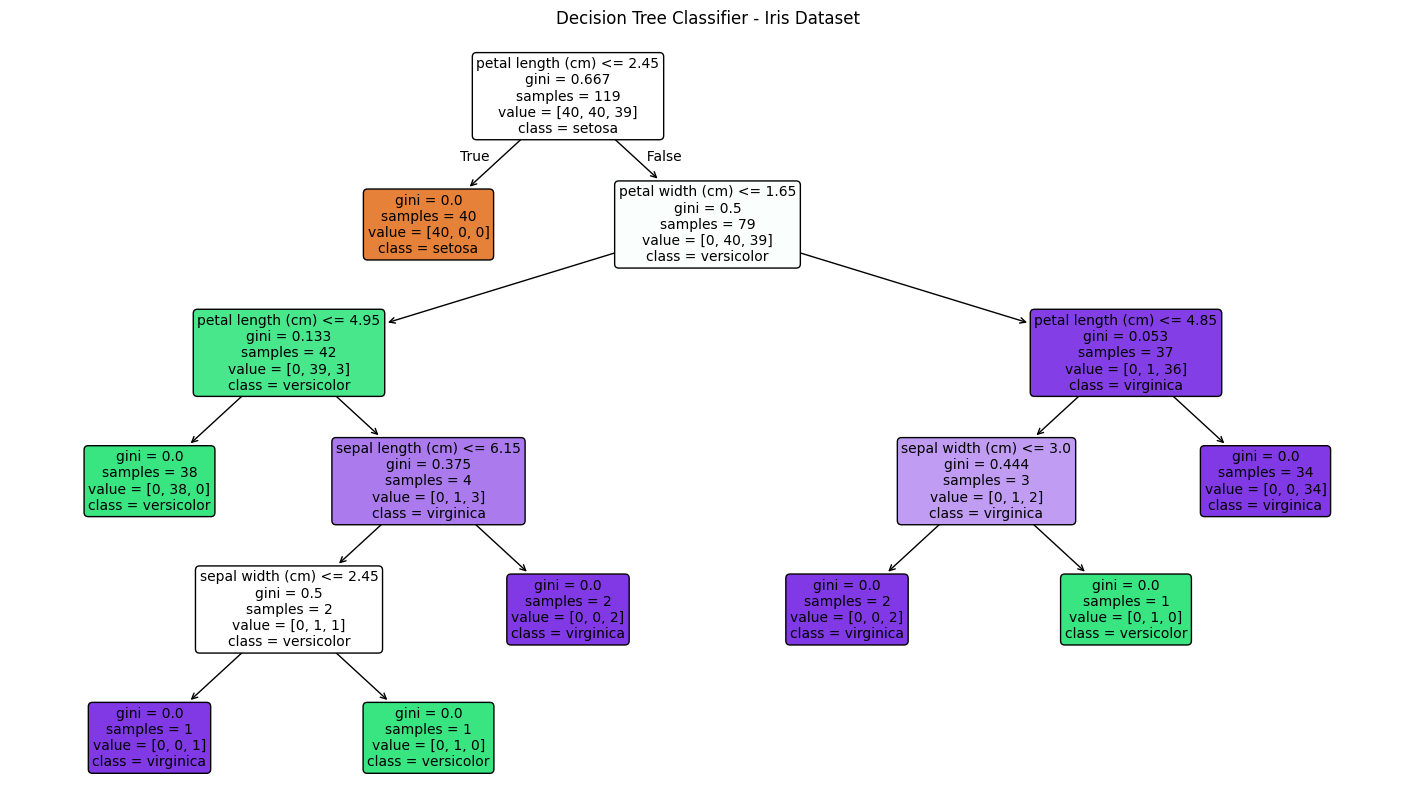

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier - Iris Dataset")
plt.show()

In [21]:
print("Maximum Tree Depth:", dt_model.get_depth())

Maximum Tree Depth: 5


In [22]:
print("Number of Leaf Nodes:", dt_model.get_n_leaves())

Number of Leaf Nodes: 8


In [23]:
root_feature = iris.feature_names[dt_model.tree_.feature[0]]

print("Root Feature:", root_feature)

Root Feature: petal length (cm)


# Task 5: Comparison of Gini Index and Entropy

Two Decision Tree classifiers were trained using different splitting criteria:

- **Gini Index**
- **Entropy**

The models were compared using:

- Accuracy
- Tree Depth
- Number of Leaf Nodes
- Root Feature

The comparison shows whether the choice of splitting criterion affects the complexity and performance of the Decision Tree. The criterion that produces a shallower tree with fewer leaf nodes can be considered the simpler model.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Gini Model
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

# Entropy Model
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

In [25]:
gini_accuracy = accuracy_score(y_test, gini_pred)
entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Gini Accuracy:", gini_accuracy)
print("Entropy Accuracy:", entropy_accuracy)

Gini Accuracy: 0.9333333333333333
Entropy Accuracy: 0.9333333333333333


In [26]:
print("Gini Tree Depth:", gini_model.get_depth())
print("Entropy Tree Depth:", entropy_model.get_depth())

Gini Tree Depth: 5
Entropy Tree Depth: 5


In [27]:
print("Gini Leaf Nodes:", gini_model.get_n_leaves())
print("Entropy Leaf Nodes:", entropy_model.get_n_leaves())

Gini Leaf Nodes: 8
Entropy Leaf Nodes: 8


In [28]:
gini_root = iris.feature_names[gini_model.tree_.feature[0]]
entropy_root = iris.feature_names[entropy_model.tree_.feature[0]]

print("Gini Root Feature:", gini_root)
print("Entropy Root Feature:", entropy_root)

Gini Root Feature: petal length (cm)
Entropy Root Feature: petal length (cm)


In [29]:
comparison = pd.DataFrame({
    "Parameter": [
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes",
        "Root Feature"
    ],
    "Gini": [
        gini_accuracy,
        gini_model.get_depth(),
        gini_model.get_n_leaves(),
        gini_root
    ],
    "Entropy": [
        entropy_accuracy,
        entropy_model.get_depth(),
        entropy_model.get_n_leaves(),
        entropy_root
    ]
})

comparison

,Parameter,Gini,Entropy
0,Accuracy,0.933333,0.933333
1,Tree Depth,5,5
2,Leaf Nodes,8,8
3,Root Feature,petal length (cm),petal length (cm)


# Task 6: Effect of Maximum Tree Depth

Decision Tree models were trained using different values of `max_depth` to study how tree depth affects model performance.

For each model, the following were recorded:

- Training Accuracy
- Testing Accuracy
- Actual Tree Depth
- Observation

A smaller maximum depth restricts the complexity of the Decision Tree, which may lead to underfitting. Increasing the depth allows the model to learn more complex patterns, but an excessively deep tree may overfit the training data and reduce its ability to generalize to unseen data.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1, 2, 3, 4, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    actual_depth = model.get_depth()

    results.append([
        depth,
        train_acc,
        test_acc,
        actual_depth
    ])

In [31]:
observations = []

for row in results:

    train_acc = row[1]
    test_acc = row[2]

    if train_acc < 0.90:
        observations.append("Underfitting")

    elif train_acc > test_acc + 0.05:
        observations.append("Overfitting")

    else:
        observations.append("Good Generalization")

In [32]:
depth_table = pd.DataFrame({
    "Max Depth": [r[0] for r in results],
    "Training Accuracy": [round(r[1],4) for r in results],
    "Testing Accuracy": [round(r[2],4) for r in results],
    "Tree Depth": [r[3] for r in results],
    "Observation": observations
})

depth_table

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.6723,0.6667,1,Underfitting
1,2.0,0.9664,0.9333,2,Good Generalization
2,3.0,0.9832,0.9667,3,Good Generalization
3,4.0,0.9916,0.9333,4,Overfitting
4,NaN,1.0000,0.9333,5,Overfitting


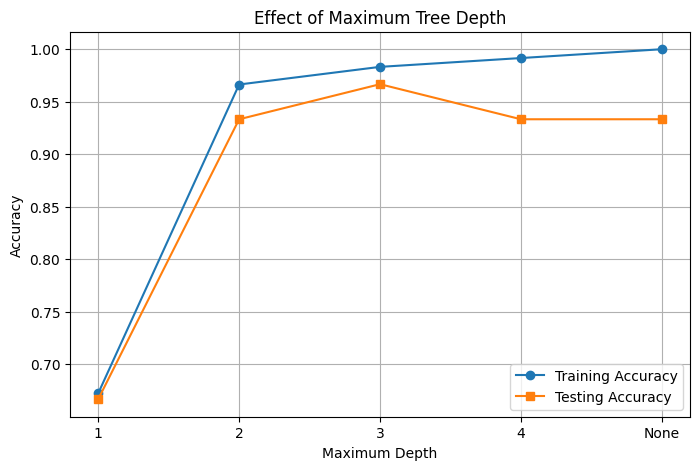

In [33]:
plt.figure(figsize=(8,5))

x = ["1","2","3","4","None"]

plt.plot(
    x,
    depth_table["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    x,
    depth_table["Testing Accuracy"],
    marker="s",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Maximum Tree Depth")
plt.legend()
plt.grid(True)

plt.show()

# Task 7: Effect of `min_samples_split`

The `min_samples_split` parameter specifies the minimum number of samples required for a node to split.

Different values of `min_samples_split` were used to analyze their effect on the complexity and performance of the Decision Tree.

Increasing `min_samples_split` reduces the number of splits, resulting in a simpler tree with fewer nodes.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

split_values = [2, 5, 10, 20]

results = []

for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        split,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

In [35]:
observations = []

for split, acc, depth, leaves in results:

    if split == 2:
        observations.append("Default tree with maximum complexity")

    elif split == 5:
        observations.append("Slightly simpler tree")

    elif split == 10:
        observations.append("Reduced complexity")

    else:
        observations.append("Simplest tree with fewer splits")

In [36]:
split_table = pd.DataFrame({
    "min_samples_split": [r[0] for r in results],
    "Accuracy": [round(r[1],4) for r in results],
    "Tree Depth": [r[2] for r in results],
    "Leaf Nodes": [r[3] for r in results],
    "Observation": observations
})

split_table

,min_samples_split,Accuracy,Tree Depth,Leaf Nodes,Observation
0,2,0.9333,5,8,Default tree with maximum complexity
1,5,0.9667,3,5,Slightly simpler tree
2,10,0.9667,3,5,Reduced complexity
3,20,0.9667,3,5,Simplest tree with fewer splits


### Observation

Increasing `min_samples_split` reduced the complexity of the Decision Tree by limiting unnecessary splits. In this experiment, increasing the value from 2 to 5 reduced the tree depth from 5 to 3 and the number of leaf nodes from 8 to 5, while improving the testing accuracy from 93.33% to 96.67%. Further increasing the value to 10 and 20 did not change the tree structure or accuracy, indicating that the simpler tree was sufficient to classify the Iris dataset effectively.

# Task 8: Effect of `min_samples_leaf`

The `min_samples_leaf` parameter specifies the minimum number of samples that each leaf node must contain.

Decision Tree models were trained using different values of `min_samples_leaf` to study how this parameter affects the complexity and classification performance of the model.

Increasing the value of `min_samples_leaf` results in larger leaf nodes, producing a simpler Decision Tree that is less likely to overfit the training data.

In [37]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        leaf,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

In [38]:
leaf_table = pd.DataFrame({
    "min_samples_leaf": [r[0] for r in results],
    "Accuracy": [round(r[1],4) for r in results],
    "Tree Depth": [r[2] for r in results],
    "Leaf Nodes": [r[3] for r in results]
})

leaf_table

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes
0,1,0.9333,5,8
1,2,0.9333,4,6
2,5,0.9333,3,5
3,10,0.9333,3,5


In [39]:
observations = []

for leaf in leaf_table["min_samples_leaf"]:

    if leaf == 1:
        observations.append("Most detailed tree")

    elif leaf == 2:
        observations.append("Slightly simpler tree")

    elif leaf == 5:
        observations.append("Reduced complexity")

    else:
        observations.append("Simplest tree with larger leaf nodes")

leaf_table["Observation"] = observations

leaf_table

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes,Observation
0,1,0.9333,5,8,Most detailed tree
1,2,0.9333,4,6,Slightly simpler tree
2,5,0.9333,3,5,Reduced complexity
3,10,0.9333,3,5,Simplest tree with larger leaf nodes


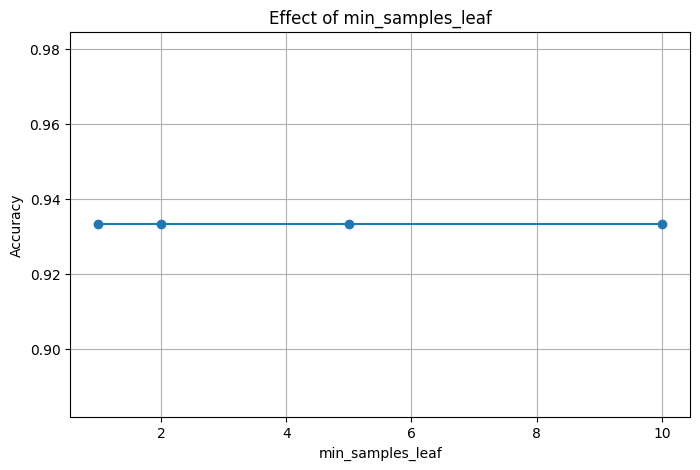

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    leaf_table["min_samples_leaf"],
    leaf_table["Accuracy"],
    marker="o"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Effect of min_samples_leaf")

plt.grid(True)

plt.show()

### Observation

The graph shows that increasing `min_samples_leaf` from 1 to 10 did not affect the testing accuracy, which remained approximately **93.33%** for all values. This indicates that the Iris dataset can be classified effectively even with larger leaf sizes. Increasing `min_samples_leaf` simplified the Decision Tree without reducing its predictive performance for this dataset.

# Task 9: Hyperparameter Tuning

GridSearchCV was used to identify the best combination of Decision Tree hyperparameters.

The following parameters were tuned:

- Criterion
- Maximum Tree Depth
- Minimum Samples Split
- Minimum Samples Leaf

The optimized model obtained from GridSearchCV was evaluated on the testing dataset and compared with the default Decision Tree classifier to determine whether hyperparameter tuning improved the model's performance.

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [43]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [44]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Score:
0.95


In [45]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)

print("Optimized Test Accuracy:", best_accuracy)

Optimized Test Accuracy: 0.9333333333333333


In [46]:
comparison = pd.DataFrame({
    "Model": ["Default Decision Tree", "Optimized Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        best_accuracy
    ]
})

comparison

,Model,Accuracy
0,Default Decision Tree,0.933333
1,Optimized Decision Tree,0.933333


# Self Learning: Visualizing Decision Tree Splits

The Decision Tree was trained using two features (Petal Length and Petal Width) to visualize how it partitions the feature space.

The colored background represents the predicted class for different regions, while the dashed lines indicate the decision boundaries created by the tree. Each split corresponds to a decision made by the Decision Tree, and each final region represents a leaf node where a class prediction is assigned.

This visualization provides an intuitive understanding of how the Decision Tree separates different Iris flower species based on feature values.

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Use only Petal Length and Petal Width
X_vis = df.iloc[:, [2, 3]]
y_vis = df["Target"]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_vis,
    test_size=0.2,
    random_state=42,
    stratify=y_vis
)

tree_vis = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_vis.fit(X_train_vis, y_train_vis)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


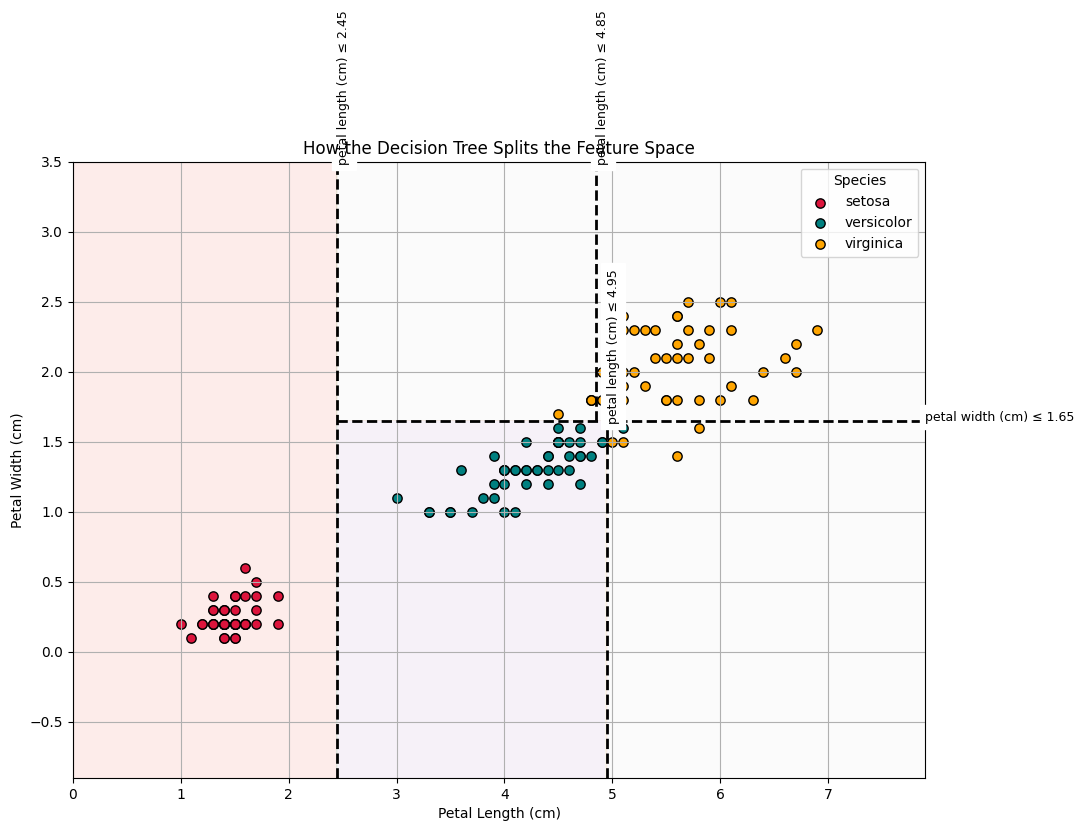

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Create mesh
x_min, x_max = X_vis.iloc[:,0].min()-1, X_vis.iloc[:,0].max()+1
y_min, y_max = X_vis.iloc[:,1].min()-1, X_vis.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = tree_vis.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(11,8))

# Background regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap="Pastel1"
)

# Scatter points
colors = ["crimson","teal","orange"]

for i, name in enumerate(iris.target_names):

    plt.scatter(
        X_vis[y_vis==i].iloc[:,0],
        X_vis[y_vis==i].iloc[:,1],
        c=colors[i],
        edgecolor="black",
        s=45,
        label=name
    )

# -------------------------
# Draw Decision Tree Splits
# -------------------------

tree = tree_vis.tree_

feature_names = X_vis.columns

def draw_splits(node, xmin, xmax, ymin, ymax):

    if tree.feature[node] == -2:
        return

    feature = tree.feature[node]
    threshold = tree.threshold[node]

    if feature == 0:
        plt.plot(
            [threshold, threshold],
            [ymin, ymax],
            'k--',
            linewidth=2
        )

        plt.text(
            threshold,
            ymax,
            f"{feature_names[0]} ≤ {threshold:.2f}",
            rotation=90,
            fontsize=9,
            backgroundcolor="white"
        )

        draw_splits(tree.children_left[node],
                    xmin,
                    threshold,
                    ymin,
                    ymax)

        draw_splits(tree.children_right[node],
                    threshold,
                    xmax,
                    ymin,
                    ymax)

    else:

        plt.plot(
            [xmin, xmax],
            [threshold, threshold],
            'k--',
            linewidth=2
        )

        plt.text(
            xmax,
            threshold,
            f"{feature_names[1]} ≤ {threshold:.2f}",
            fontsize=9,
            backgroundcolor="white"
        )

        draw_splits(tree.children_left[node],
                    xmin,
                    xmax,
                    ymin,
                    threshold)

        draw_splits(tree.children_right[node],
                    xmin,
                    xmax,
                    threshold,
                    ymax)

draw_splits(
    0,
    x_min,
    x_max,
    y_min,
    y_max
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("How the Decision Tree Splits the Feature Space")

plt.legend(title="Species")

plt.grid(True)

plt.show()